# Predicting Airline Passenger Satisfaction — Playground S6E10

Binary classification of `satisfaction` (True/False). Submissions are probabilities, scored by ROC-AUC.

**Plan:** EDA → feature engineering → 5-fold stratified CV with LightGBM + XGBoost (optionally augmented with the original
airline dataset) → OOF-weighted blend → submit via the Kaggle CLI.

In [1]:
import os, subprocess, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score
from scipy.optimize import minimize

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)

COMP = 'playground-series-s6e10'
SEED = 42
N_FOLDS = 5
TARGET = 'satisfaction'

# Plot styling: one fixed colour per class, recessive grid
C_SAT, C_DIS = '#2a78d6', '#eb6834'      # satisfied (blue), not satisfied (orange)
CLASS_PAL = {True: C_SAT, False: C_DIS}
plt.rcParams.update({
    'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#e6e5e1', 'grid.linewidth': 0.6, 'axes.axisbelow': True,
    'axes.edgecolor': '#9a9994', 'axes.titleweight': 'bold', 'axes.titlesize': 11, 'font.size': 9,
})

## 1. Load data

In [2]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
sample = pd.read_csv('sample_submission.csv')

# Original dataset this synthetic data was generated from (Kaggle: teejmahal20/airline-passenger-satisfaction).
# Optional: only used if the folder exists. Download with:
#   kaggle datasets download teejmahal20/airline-passenger-satisfaction -p original --unzip
HAS_ORIG = os.path.exists('original/train.csv')
if HAS_ORIG:
    orig = pd.concat([pd.read_csv('original/train.csv'), pd.read_csv('original/test.csv')], ignore_index=True)
    orig = orig.drop(columns=['Unnamed: 0', 'id', 'Inflight service'])   # 'Inflight service' not in competition data
    orig[TARGET] = orig[TARGET].eq('satisfied')
    print('original:', orig.shape)

print('train:', train.shape, ' test:', test.shape)
train.head()

original: (129880, 22)
train: (699635, 23)  test: (299844, 22)


,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,Gender,Customer Type,Type of Travel,Class,satisfaction
0,0,36,694,4,4,4,3,1,4,1,1,3,4,4,3,1,0,0.0,Female,Loyal Customer,Personal Travel,Eco,False
1,1,56,651,5,5,5,5,5,4,4,5,5,5,5,4,3,0,0.0,Male,Loyal Customer,Business travel,Business,True
2,2,31,1371,3,4,2,5,3,3,3,3,4,3,4,5,3,0,0.0,Female,Loyal Customer,Personal Travel,Eco,False
3,3,10,1616,3,5,3,3,3,3,3,3,4,5,3,4,3,0,0.0,Male,Loyal Customer,Personal Travel,Eco,False
4,4,23,481,3,4,3,4,5,3,5,5,5,4,5,3,5,5,0.0,Female,disloyal Customer,Business travel,Eco,False


## 2. EDA
### 2.1 Structure, missing values, duplicates

In [3]:
CATS = ['Gender', 'Customer Type', 'Type of Travel', 'Class']
RATINGS = ['Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location',
           'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service',
           'Leg room service', 'Baggage handling', 'Checkin service', 'Cleanliness']
NUMS = ['Age', 'Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']
FEATURES = NUMS + RATINGS + CATS

summary = pd.DataFrame({
    'dtype': train[FEATURES].dtypes.astype(str),
    'n_unique': train[FEATURES].nunique(),
    'train_missing': train[FEATURES].isna().sum(),
    'test_missing': test[FEATURES].isna().sum(),
})
display(summary)
print('Duplicate feature rows in train:', train.duplicated(FEATURES).sum())
print('Test rows whose features appear in train:', test[FEATURES].merge(train[FEATURES].drop_duplicates(), how='inner').shape[0])

,dtype,n_unique,train_missing,test_missing
Age,int64,75,0,0
Flight Distance,int64,3474,0,0
Departure Delay in Minutes,int64,167,0,0
Arrival Delay in Minutes,float64,168,292,130
Inflight wifi service,int64,6,0,0
Departure/Arrival time convenient,int64,6,0,0
Ease of Online booking,int64,6,0,0
Gate location,int64,6,0,0
Food and drink,int64,6,0,0
Online boarding,int64,6,0,0


Duplicate feature rows in train: 0


Test rows whose features appear in train: 0


### 2.2 Target balance

In [4]:
rate = train[TARGET].mean()
print(f'Satisfied: {rate:.2%}   Not satisfied: {1 - rate:.2%}   (mildly imbalanced; AUC is insensitive to this)')
if HAS_ORIG:
    print(f'Original dataset satisfied rate: {orig[TARGET].mean():.2%}')

Satisfied: 44.36%   Not satisfied: 55.64%   (mildly imbalanced; AUC is insensitive to this)
Original dataset satisfied rate: 43.45%


### 2.3 Numeric features by target

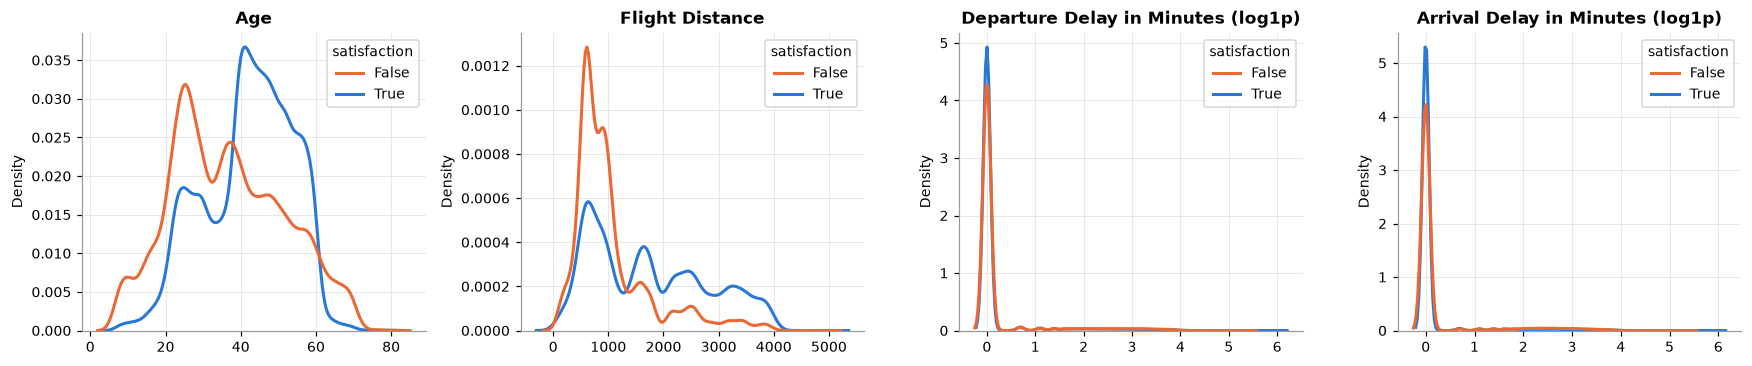

satisfaction                         False     True 
Age                        count  389296.0  310339.0
                           mean       36.5      42.1
                           std        14.9      11.6
                           min         7.0       7.0
                           25%        25.0      34.0
                           50%        35.0      43.0
                           75%        48.0      51.0
                           max        85.0      85.0
Flight Distance            count  389296.0  310339.0
                           mean     1038.4    1749.3
                           std       717.0    1061.9
                           min        67.0      67.0
                           25%       591.0     771.0
                           50%       841.0    1605.0
                           75%      1167.0    2563.0
                           max      4983.0    4983.0
Departure Delay in Minutes count  389296.0  310339.0
                           mean        1.4       0.9
                           std         6.5       5.2
                           min         0.0       0.0
                           25%         0.0       0.0
                           50%         0.0       0.0
                           75%         0.0       0.0
                           max       472.0     489.0
Arrival Delay in Minutes   count  389110.0  310233.0
                           mean        1.4       0.8
                           std         6.3       4.9
                           min         0.0       0.0
                           25%         0.0       0.0
                           50%         0.0       0.0
                           75%         0.0       0.0
                           max       446.0     491.0

Share of zero departure delay: 0.908
Departure vs arrival delay correlation: 0.842


In [5]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.4))
for ax, col in zip(axes, NUMS):
    data = train[[col, TARGET]].copy()
    log = 'Delay' in col
    if log:
        data[col] = np.log1p(data[col])
    sns.kdeplot(data=data.sample(100_000, random_state=SEED), x=col, hue=TARGET, palette=CLASS_PAL,
                common_norm=False, linewidth=2, ax=ax, warn_singular=False)
    ax.set_title(col + (' (log1p)' if log else ''))
    ax.set_xlabel('')
plt.tight_layout(); plt.show()

display(train.groupby(TARGET)[NUMS].describe().T.round(1))
print('Share of zero departure delay:', (train['Departure Delay in Minutes'] == 0).mean().round(3))
print('Departure vs arrival delay correlation:',
      train[['Departure Delay in Minutes', 'Arrival Delay in Minutes']].corr().iloc[0, 1].round(3))

### 2.4 Service ratings — satisfaction rate per rating level
Ratings are 0–5 where **0 = not applicable**. The heatmap shows P(satisfied) for each rating value.

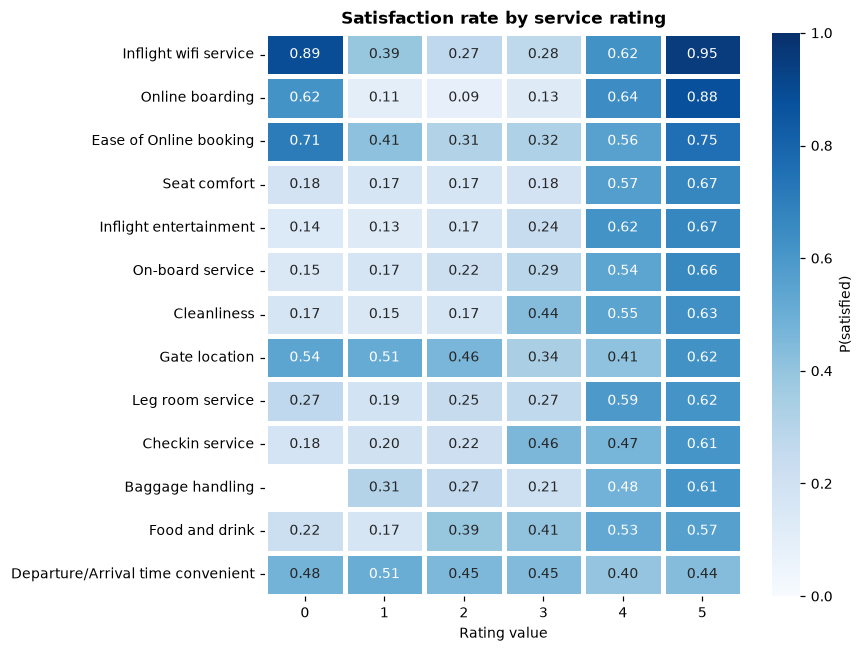

Counts per rating value (0 = N/A is rare):


,0,1,2,3,4,5
Inflight wifi service,13102,107739,186870,184436,128136,79352
Online boarding,9147,57588,119297,149783,210950,152870
Ease of Online booking,16073,110934,174868,175267,130695,91798
Seat comfort,838,63130,92471,120182,226726,196288
Inflight entertainment,1020,70131,113341,122977,210098,182068
On-board service,801,61164,87014,150812,225949,173895
Cleanliness,945,72518,102596,169931,190681,162964
Gate location,1455,104611,130300,202277,168488,92504
Leg room service,1693,53094,126775,131580,204124,182369
Checkin service,929,66468,74919,200177,209592,147550


In [6]:
rate_tbl = pd.DataFrame({c: train.groupby(c)[TARGET].mean() for c in RATINGS}).T
cnt_tbl = pd.DataFrame({c: train[c].value_counts() for c in RATINGS}).T.fillna(0).astype(int)
order = rate_tbl[5].sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(rate_tbl.loc[order], annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1,
            linewidths=2, linecolor='white', cbar_kws={'label': 'P(satisfied)'}, ax=ax)
ax.set_xlabel('Rating value'); ax.set_ylabel(''); ax.set_title('Satisfaction rate by service rating')
ax.grid(False)
plt.tight_layout(); plt.show()
print('Counts per rating value (0 = N/A is rare):')
display(cnt_tbl.loc[order])

### 2.5 Categorical features

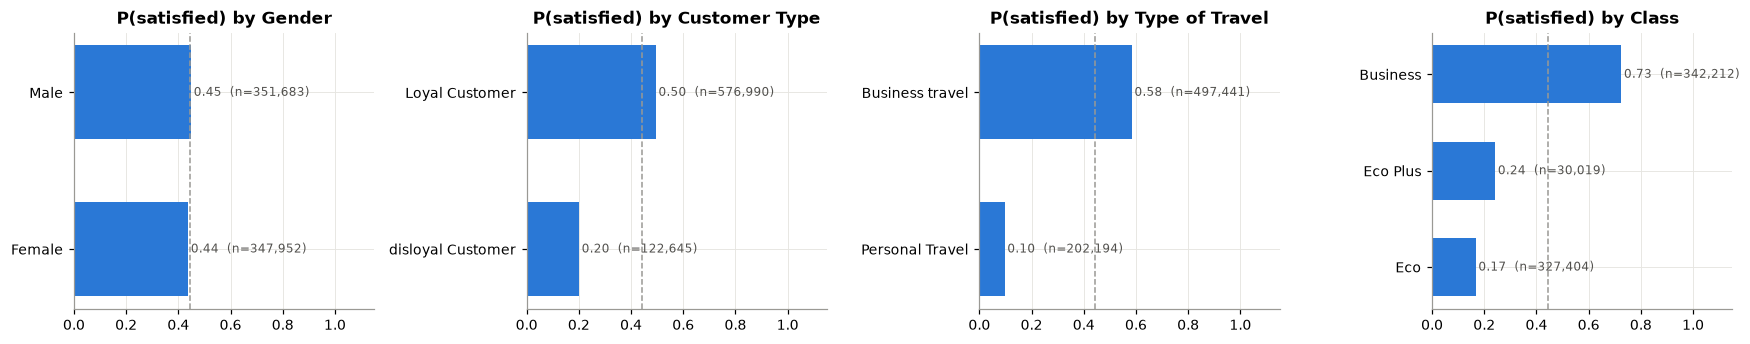

Type of Travel,Business travel,Personal Travel
Class,,
Business,0.732,0.112
Eco,0.260,0.097
Eco Plus,0.346,0.095


In [7]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.2))
for ax, col in zip(axes, CATS):
    g = train.groupby(col)[TARGET].agg(['mean', 'size']).sort_values('mean')
    ax.barh(g.index.astype(str), g['mean'], color=C_SAT, height=0.6)
    for i, (m, n) in enumerate(zip(g['mean'], g['size'])):
        ax.text(m + 0.01, i, f'{m:.2f}  (n={n:,})', va='center', fontsize=8, color='#52514e')
    ax.axvline(rate, color='#9a9994', ls='--', lw=1)
    ax.set_xlim(0, 1.15); ax.set_title(f'P(satisfied) by {col}')
plt.tight_layout(); plt.show()

# Interaction: Class x Type of Travel is the main segmentation
display(pd.crosstab(train['Class'], train['Type of Travel'], values=train[TARGET], aggfunc='mean').round(3))

### 2.6 Single-feature predictive power and correlations

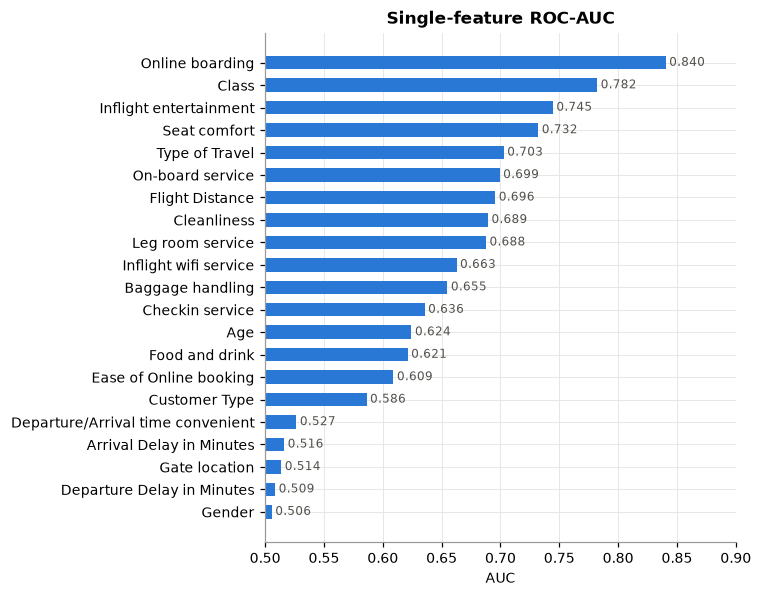

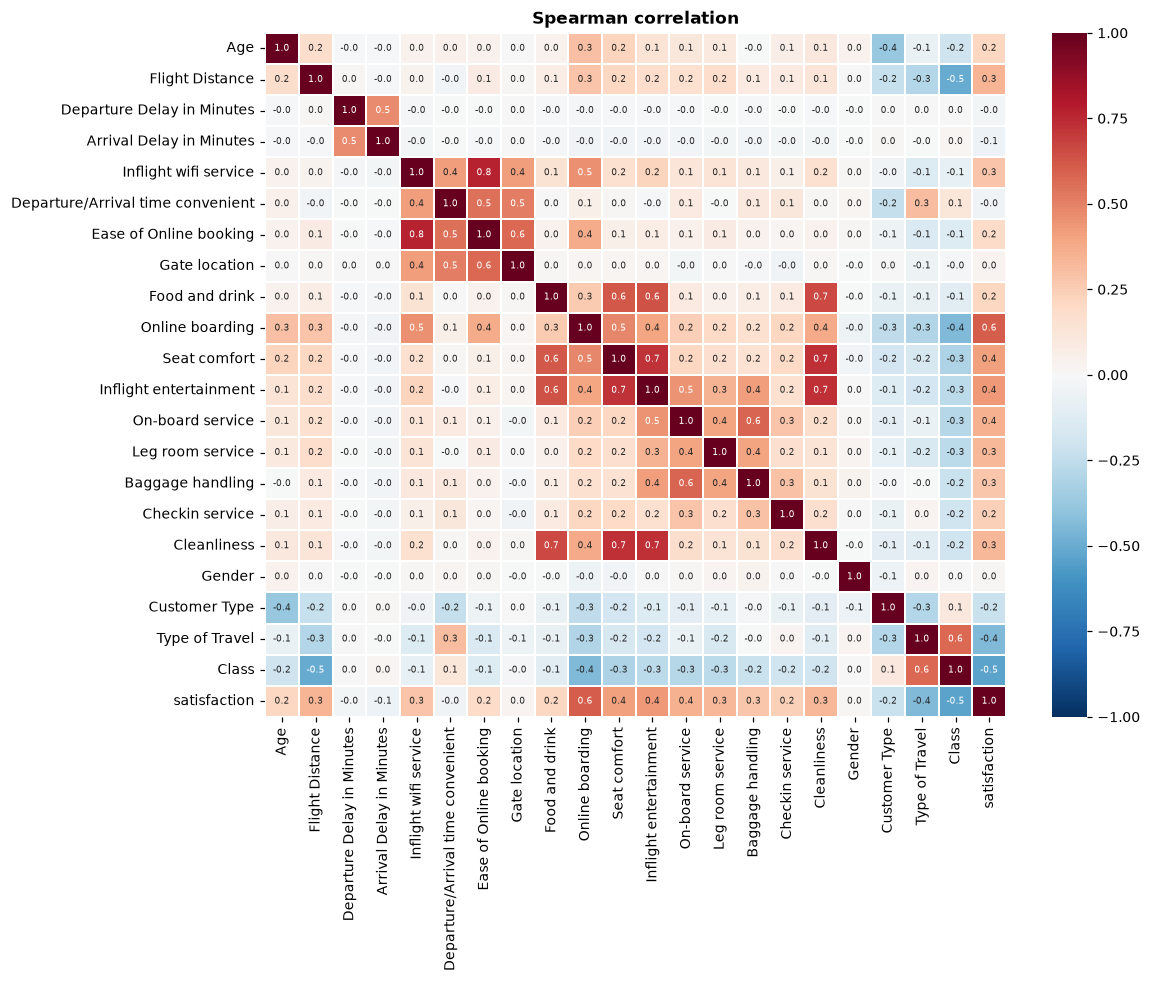

In [8]:
y = train[TARGET].astype(int)
uni = {}
for c in FEATURES:
    x = train[c]
    if c in CATS:
        x = x.map(train.groupby(c)[TARGET].mean())
    a = roc_auc_score(y, x.fillna(-1))
    uni[c] = max(a, 1 - a)
uni = pd.Series(uni).sort_values()

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.barh(uni.index, uni.values - 0.5, left=0.5, color=C_SAT, height=0.6)
for i, v in enumerate(uni.values):
    ax.text(v + 0.003, i, f'{v:.3f}', va='center', fontsize=8, color='#52514e')
ax.set_xlim(0.5, 0.9); ax.set_title('Single-feature ROC-AUC'); ax.set_xlabel('AUC')
plt.tight_layout(); plt.show()

enc = train[FEATURES + [TARGET]].copy()
for c in CATS:
    enc[c] = enc[c].astype('category').cat.codes
corr = enc.astype(float).corr(method='spearman')
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, cmap='RdBu_r', center=0, vmin=-1, vmax=1, linewidths=1, linecolor='white',
            annot=True, fmt='.1f', annot_kws={'size': 6}, ax=ax)
ax.set_title('Spearman correlation'); ax.grid(False)
plt.tight_layout(); plt.show()

### 2.7 Train vs test (adversarial validation) and synthetic vs original

In [9]:
def to_cat(df):
    df = df.copy()
    for c in CATS:
        df[c] = pd.Categorical(df[c].astype(str), categories=sorted(train[c].astype(str).unique()))
    return df

adv_p = dict(objective='binary', learning_rate=0.1, num_leaves=63, verbose=-1, n_jobs=-1, seed=SEED)

def adversarial_auc(a, b):
    X = to_cat(pd.concat([a[FEATURES], b[FEATURES]], ignore_index=True))
    t = np.r_[np.zeros(len(a)), np.ones(len(b))]
    Xa, Xb, ta, tb = train_test_split(X, t, test_size=0.3, random_state=SEED, stratify=t)
    m = lgb.train(adv_p, lgb.Dataset(Xa, ta), 200)
    return roc_auc_score(tb, m.predict(Xb))

print(f'Adversarial AUC train vs test: {adversarial_auc(train, test):.4f}   (~0.5 => same distribution)')
if HAS_ORIG:
    print(f'Adversarial AUC train vs original: {adversarial_auc(train, orig):.4f}')

Adversarial AUC train vs test: 0.4981   (~0.5 => same distribution)


Adversarial AUC train vs original: 0.8353


**EDA takeaways**
- Online boarding, inflight wifi, Class and Type of Travel dominate; ratings behave ordinally, with 0 meaning "not applicable".
- Delays are heavily zero-inflated and weakly predictive on their own; arrival delay has a few missing values (trees handle NaN natively).
- Train and test come from the same distribution, so CV should track the leaderboard.

## 3. Feature engineering

In [10]:
def make_features(df):
    df = df[FEATURES].copy()
    r = df[RATINGS].replace(0, np.nan)          # 0 = not applicable
    df['rating_mean'] = r.mean(axis=1)
    df['rating_std'] = r.std(axis=1)
    df['rating_min'] = r.min(axis=1)
    df['rating_max'] = r.max(axis=1)
    df['n_zero_ratings'] = (df[RATINGS] == 0).sum(axis=1)
    df['n_rating_5'] = (df[RATINGS] == 5).sum(axis=1)
    df['digital_score'] = df[['Inflight wifi service', 'Online boarding', 'Ease of Online booking']].mean(axis=1)
    df['comfort_score'] = df[['Seat comfort', 'Inflight entertainment', 'Leg room service', 'Cleanliness']].mean(axis=1)
    df['delay_diff'] = df['Arrival Delay in Minutes'] - df['Departure Delay in Minutes']
    df['total_delay'] = df['Arrival Delay in Minutes'].fillna(df['Departure Delay in Minutes']) + df['Departure Delay in Minutes']
    df['delay_per_km'] = df['total_delay'] / (df['Flight Distance'] + 1)
    df['class_travel'] = df['Class'].astype(str) + '_' + df['Type of Travel'].astype(str)
    df = to_cat(df)
    df['class_travel'] = pd.Categorical(df['class_travel'],
        categories=sorted((train['Class'].astype(str) + '_' + train['Type of Travel'].astype(str)).unique()))
    return df

X = make_features(train)
y = train[TARGET].astype(int).values
X_test = make_features(test)
if HAS_ORIG:
    X_orig = make_features(orig)
    y_orig = orig[TARGET].astype(int).values
print(X.shape, X_test.shape)

(699635, 33) (299844, 33)


## 4. Cross-validated models
5-fold stratified CV. When the original dataset is used, it is appended to the **training** part of every fold only,
so validation folds remain purely competition data and the OOF AUC stays honest.

In [11]:
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
FOLDS = list(skf.split(X, y))

def run_cv(name, fit_predict, use_orig=False, X_=X, Xt_=X_test, Xo_=None):
    oof = np.zeros(len(X_)); pred = np.zeros(len(Xt_)); t0 = time.time()
    for k, (tr_idx, va_idx) in enumerate(FOLDS):
        Xtr, ytr = X_.iloc[tr_idx], y[tr_idx]
        if use_orig:
            Xtr = pd.concat([Xtr, Xo_ if Xo_ is not None else X_orig], ignore_index=True)
            ytr = np.r_[ytr, y_orig]
        oof[va_idx], p = fit_predict(Xtr, ytr, X_.iloc[va_idx], y[va_idx], Xt_)
        pred += p / N_FOLDS
        print(f'  fold {k}: {roc_auc_score(y[va_idx], oof[va_idx]):.5f}')
    score = roc_auc_score(y, oof)
    print(f'{name}: OOF AUC {score:.5f}  ({time.time() - t0:.0f}s)')
    return dict(oof=oof, pred=pred, score=score)

results = {}

In [12]:
LGB_PARAMS = dict(objective='binary', metric='auc', learning_rate=0.03, num_leaves=63, min_child_samples=40,
                  subsample=0.8, subsample_freq=1, colsample_bytree=0.5, reg_alpha=0.1, reg_lambda=2.0,
                  cat_smooth=10, verbose=-1, n_jobs=-1, seed=SEED)

def lgb_fit_predict(Xtr, ytr, Xva, yva, Xte, params=LGB_PARAMS):
    m = lgb.train(params, lgb.Dataset(Xtr, ytr), 10000, valid_sets=[lgb.Dataset(Xva, yva)],
                  callbacks=[lgb.early_stopping(300, verbose=False)])
    return m.predict(Xva, num_iteration=m.best_iteration), m.predict(Xte, num_iteration=m.best_iteration)

results['lgb'] = run_cv('LightGBM', lgb_fit_predict)
if HAS_ORIG:
    results['lgb_orig'] = run_cv('LightGBM + original', lgb_fit_predict, use_orig=True)

  fold 0: 0.95905


  fold 1: 0.95772


  fold 2: 0.95943


  fold 3: 0.95880


  fold 4: 0.95904


...

  fold 1: 0.95743


  fold 2: 0.95929


  fold 3: 0.95833


  fold 4: 0.95894


LightGBM + original: OOF AUC 0.95861  (1546s)


In [13]:
# LightGBM variant treating every rating as categorical (different split structure -> blend diversity)
def ratings_as_cat(df):
    df = df.copy()
    for c in RATINGS:
        df[c] = pd.Categorical(df[c], categories=range(6))
    return df

Xc, Xc_test = ratings_as_cat(X), ratings_as_cat(X_test)
Xc_orig = ratings_as_cat(X_orig) if HAS_ORIG else None
use_orig = HAS_ORIG and results['lgb_orig']['score'] > results['lgb']['score']
print('Using original data for remaining models:', use_orig)
results['lgb_catrat'] = run_cv('LightGBM (ratings as categorical)', lgb_fit_predict, use_orig=use_orig,
                               X_=Xc, Xt_=Xc_test, Xo_=Xc_orig)

Using original data for remaining models: False


  fold 0: 0.95904


  fold 1: 0.95768


  fold 2: 0.95940


  fold 3: 0.95869


  fold 4: 0.95910


LightGBM (ratings as categorical): OOF AUC 0.95878  (1414s)


In [14]:
XGB_PARAMS = dict(objective='binary:logistic', eval_metric='auc', tree_method='hist', learning_rate=0.03,
                  max_depth=7, min_child_weight=5, subsample=0.8, colsample_bytree=0.5, reg_lambda=2.0,
                  max_cat_to_onehot=1, n_jobs=-1, seed=SEED)

def xgb_fit_predict(Xtr, ytr, Xva, yva, Xte):
    dtr = xgb.DMatrix(Xtr, ytr, enable_categorical=True)
    dva = xgb.DMatrix(Xva, yva, enable_categorical=True)
    m = xgb.train(XGB_PARAMS, dtr, 10000, evals=[(dva, 'va')], early_stopping_rounds=300, verbose_eval=False)
    rng = (0, m.best_iteration + 1)
    return (m.predict(dva, iteration_range=rng),
            m.predict(xgb.DMatrix(Xte, enable_categorical=True), iteration_range=rng))

results['xgb'] = run_cv('XGBoost', xgb_fit_predict, use_orig=use_orig)

  fold 0: 0.95884


  fold 1: 0.95739


  fold 2: 0.95943


  fold 3: 0.95848


  fold 4: 0.95905


XGBoost: OOF AUC 0.95863  (1794s)


## 5. Blend

In [15]:
names = list(results)
display(pd.Series({n: results[n]['score'] for n in names}, name='OOF AUC').sort_values(ascending=False).round(5))
display(pd.DataFrame({n: results[n]['oof'] for n in names}).corr().round(4))

from scipy.stats import rankdata
R_oof = np.column_stack([rankdata(results[n]['oof']) / len(y) for n in names])
R_test = np.column_stack([rankdata(results[n]['pred']) / len(X_test) for n in names])

def neg_auc(w):
    w = np.abs(w) / np.abs(w).sum()
    return -roc_auc_score(y, R_oof @ w)

res = minimize(neg_auc, np.ones(len(names)) / len(names), method='Nelder-Mead', options={'maxiter': 300})
w = np.abs(res.x) / np.abs(res.x).sum()
print('Blend weights:', dict(zip(names, w.round(3))))
print(f'Blend OOF AUC: {-res.fun:.5f}   (best single: {max(results[n]["score"] for n in names):.5f})')
blend_test = R_test @ w

lgb           0.95880
lgb_catrat    0.95878
xgb           0.95863
lgb_orig      0.95861
Name: OOF AUC, dtype: float64

,lgb,lgb_orig,lgb_catrat,xgb
lgb,1.0000,0.9991,0.9995,0.9993
lgb_orig,0.9991,1.0000,0.9989,0.9987
lgb_catrat,0.9995,0.9989,1.0000,0.9990
xgb,0.9993,0.9987,0.9990,1.0000


Blend weights: {'lgb': np.float64(0.235), 'lgb_orig': np.float64(0.242), 'lgb_catrat': np.float64(0.336), 'xgb': np.float64(0.188)}
Blend OOF AUC: 0.95896   (best single: 0.95880)


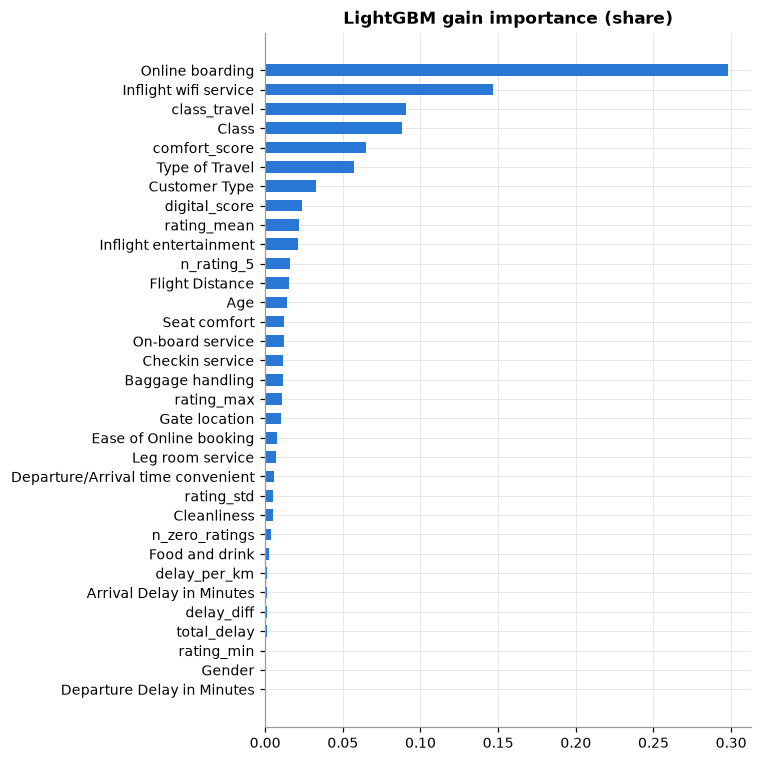

In [16]:
# Feature importance (LightGBM, full train) for reference
m_full = lgb.train({**LGB_PARAMS, 'learning_rate': 0.05}, lgb.Dataset(X, y), 800)
imp = pd.Series(m_full.feature_importance('gain'), X.columns).sort_values()
imp = imp / imp.sum()
fig, ax = plt.subplots(figsize=(7, 7))
ax.barh(imp.index, imp.values, color=C_SAT, height=0.6)
ax.set_title('LightGBM gain importance (share)')
plt.tight_layout(); plt.show()

## 6. Submission

In [17]:
sub = sample[['id']].copy()
assert (sub['id'].values == test['id'].values).all()
sub[TARGET] = blend_test
sub.to_csv('submission.csv', index=False)
print(sub.shape); display(sub.head())

(299844, 2)


,id,satisfaction
0,699635,0.525622
1,699636,0.622817
2,699637,0.627929
3,699638,0.425902
4,699639,0.384147


In [ ]:
import io

def kaggle_cli(*args):
    # The CLI prints a UTF-8 progress bar; Windows' default cp1252 decoding crashes on it
    return subprocess.run(['kaggle', 'competitions', *args], capture_output=True, text=True,
                          encoding='utf-8', errors='replace')

SUBMIT = True
msg = f'LGB+XGB rank blend | OOF AUC {-res.fun:.5f} | orig={use_orig}'

# Re-running this cell must not burn another daily submission on the same blend
prev = pd.read_csv(io.StringIO(kaggle_cli('submissions', '-c', COMP, '-v').stdout))
if SUBMIT and msg in prev['description'].values:
    print(f'Already submitted "{msg}" - skipping. Set a new message or delete this guard to resubmit.')
elif SUBMIT:
    out = kaggle_cli('submit', '-c', COMP, '-f', 'submission.csv', '-m', msg)
    print(out.stdout[-2000:], out.stderr[-300:])

In [ ]:
# Check the leaderboard score (may take a minute to appear after submitting)
time.sleep(60)
out = kaggle_cli('submissions', '-c', COMP)
print(out.stdout[:1500], out.stderr[-500:])